In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from mpl_toolkits.mplot3d import Axes3D

import sys, os
sys.path.append(os.path.abspath(".."))

import seaborn as sns


In [2]:
# Load training data
data = pd.read_csv('../data/claims_train.csv')

In [4]:
df = data.copy()

# Cap exposure
df["Exposure"] = df["Exposure"].clip(upper=1.0)

# Drop NaNs and ID
df = df.dropna()
df = df.drop(columns=["IDpol"], errors="ignore")

# Targets
y_rate = (df["ClaimNb"] / df["Exposure"]).astype(float)
w_expo = df["Exposure"].astype(float)

# Feature engineering
df["LogBonus"] = np.log(df["BonusMalus"])
df["LogDensity"] = np.log(df["Density"])

cats_to_encode = ["VehBrand", "VehGas", "Region", "Area"]
keep_cols = ["VehPower", "VehAge", "DrivAge", "LogBonus", "LogDensity"]

X = pd.get_dummies(
    df[keep_cols + cats_to_encode],
    columns=cats_to_encode,
    drop_first=True
)

# Scale for PCA
X_scaled = StandardScaler().fit_transform(X)

numeric_cols = keep_cols
dummy_cols = [c for c in X.columns if c not in numeric_cols]



In [5]:

# Numeric only
X_num = X[numeric_cols]
X_num_scaled = StandardScaler().fit_transform(X_num)

# Numeric only PCA
pca_num = PCA().fit(X_num_scaled)
expl_num = pca_num.explained_variance_ratio_
cum_num = np.cumsum(expl_num)


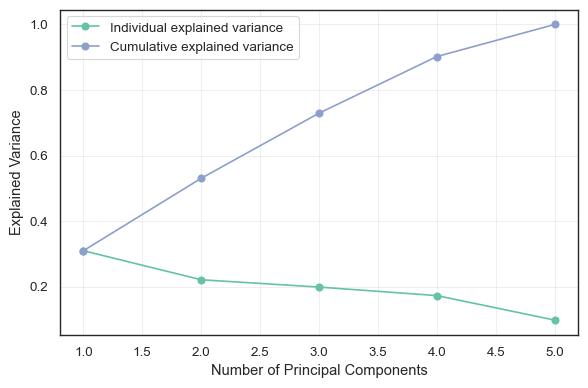

In [34]:

sns.set_theme(style="white", context="paper", font_scale=1.1)

pcs_num = np.arange(1, len(expl_num) + 1)

plt.figure(figsize=(6, 4))

# Individual explained variance
plt.plot(
    pcs_num,
    expl_num,
    marker='o',
    label='Individual explained variance',
    color=sns.color_palette("Set2")[0]
)

# Cumulative explained variance
plt.plot(
    pcs_num,
    cum_num,
    marker='o',
    label='Cumulative explained variance',
    color=sns.color_palette("Set2")[2]
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "/Users/joakimandersen/Desktop/Machine learning/1screeplot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


PCA: Variation trade off vs pc's


------------------------------
--- 2 PCs --- variance explained = 0.531
k=2: silhouette=0.402
k=3: silhouette=0.373
k=4: silhouette=0.330
k=5: silhouette=0.320
k=6: silhouette=0.333

------------------------------
--- 3 PCs --- variance explained = 0.729
k=2: silhouette=0.316
k=3: silhouette=0.264
k=4: silhouette=0.291
k=5: silhouette=0.267
k=6: silhouette=0.235

------------------------------
--- 4 PCs --- variance explained = 0.902
k=2: silhouette=0.258
k=3: silhouette=0.217
k=4: silhouette=0.231
k=5: silhouette=0.219
k=6: silhouette=0.210


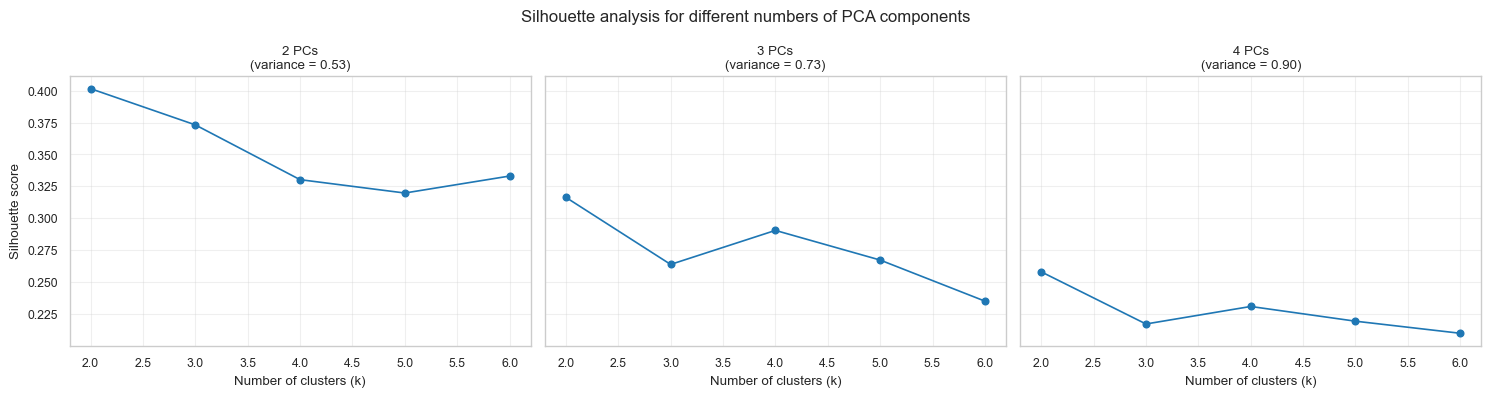

In [31]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, n in zip(axes, [2, 3, 4]):
    print("\n" + "-"*30)
    
    # PCA on scaled numeric data
    pca = PCA(n_components=n, random_state=7)
    X_pca = pca.fit_transform(X_num_scaled)

    # Variance explained
    var = pca.explained_variance_ratio_.sum()

    # Subsample for silhouette
    sample_size = min(5000, len(X_pca))
    idx = rng.choice(len(X_pca), size=sample_size, replace=False)

    print(f"--- {n} PCs --- variance explained = {var:.3f}")

    silhouette_scores = []
    K = [2, 3, 4, 5, 6]

    for k in K:
        labels = KMeans(
            n_clusters=k,
            n_init=10,
            random_state=42
        ).fit_predict(X_pca)

        score = silhouette_score(X_pca[idx], labels[idx])
        silhouette_scores.append(score)

        print(f"k={k}: silhouette={score:.3f}")

    # ---- Plot ----
    ax.plot(K, silhouette_scores, marker="o")
    ax.set_title(f"{n} PCs\n(variance = {var:.2f})")
    ax.set_xlabel("Number of clusters (k)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Silhouette score")

fig.suptitle("Silhouette analysis for different numbers of PCA components", fontsize=12)
plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/1silhouetteTuning", dpi=300, bbox_inches="tight")
plt.show()


Choose between more variance explained, and higher silhouette meaning more partitioning in data by clustering


we choose 2pc, k=3

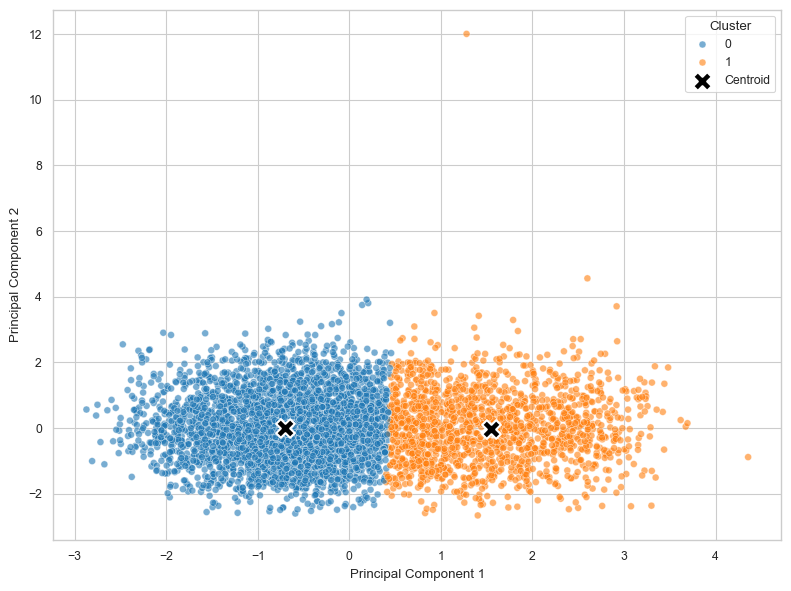

In [35]:
# --- Seaborn style ---
sns.set_theme(style="whitegrid", context="paper", palette="tab10")

# --- PCA (2 components) ---
pca = PCA(n_components=2, random_state=42)
X_pca_2d = pca.fit_transform(X_num_scaled)

# --- KMeans (k = 2) ---
kmeans = KMeans(n_clusters=2, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_pca_2d)

# --- Fixed colors for clusters across ALL plots ---
cluster_order = sorted(np.unique(labels))   # [0, 1, 2]
base = sns.color_palette("tab10", n_colors=len(cluster_order))
palette_map = {c: base[i] for i, c in enumerate(cluster_order)}

# --- Optional subsample for cleaner plot ---
rng = np.random.default_rng(42)
sample_size = min(5000, len(X_pca_2d))
idx = rng.choice(len(X_pca_2d), size=sample_size, replace=False)




# --- Prepare plotting DataFrame ---
plot_df = pd.DataFrame(
    X_pca_2d[idx],
    columns=["PC1", "PC2"]
)
plot_df["Cluster"] = labels[idx].astype(int)

centroids_df = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["PC1", "PC2"]
)

# --- Plot ---
plt.figure(figsize=(8, 6))

ax = sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    hue_order=cluster_order,
    palette=palette_map,
    alpha=0.6,
    s=25
)

plt.scatter(
    centroids_df["PC1"],
    centroids_df["PC2"],
    c="black",
    s=180,
    marker="X",
    edgecolors="white",
    linewidths=1.5,
    label="Centroid"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/1PCAClustering", dpi=300, bbox_inches="tight")
plt.show()



Top 5 (signed) loadings for PC1:
LogBonus      0.692632
DrivAge      -0.668627
LogDensity    0.192987
VehAge        0.137741
VehPower     -0.130313
Name: PC1, dtype: float64

Top 5 (signed) loadings for PC2:
VehAge        0.709404
LogDensity   -0.697488
VehPower     -0.083979
DrivAge      -0.054527
LogBonus     -0.015173
Name: PC2, dtype: float64


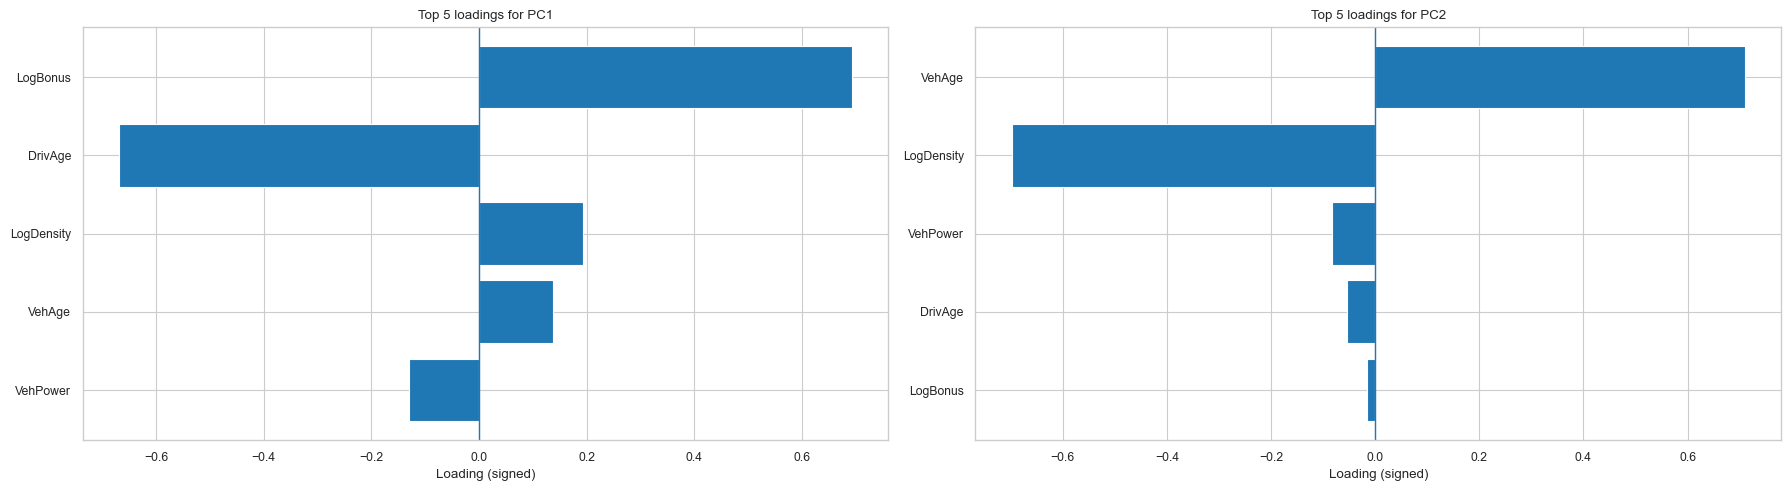

In [28]:
for i in range(pca.n_components_):
    pc = loadings.iloc[:, i].sort_values(key=lambda s: s.abs(), ascending=False).head(5)
    print(f"\nTop 5 (signed) loadings for PC{i+1}:")
    print(pc)

fig, axes = plt.subplots(1, pca.n_components_, figsize=(18, 5))
for i, ax in enumerate(axes):
    pc = loadings.iloc[:, i].sort_values(key=lambda s: s.abs(), ascending=False).head(5)
    ax.barh(pc.index[::-1], pc.values[::-1])   # signed values
    ax.axvline(0, linewidth=1)                 # shows +/- clearly
    ax.set_title(f"Top 5 loadings for PC{i+1}")
    ax.set_xlabel("Loading (signed)")
plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/1LoadingPCA", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# ✅ Cleaned + fixed version
data["Claim_rate"] = (data["ClaimNb"] / data["Exposure"]).astype(float)

# Add cluster labels from your PCA/KMeans results
data["Cluster"] = labels

# Select key columns for summary
cols = ["ClaimNb", "Exposure", "Claim_rate", "DrivAge", "VehAge", "VehPower", "BonusMalus", "Density"]
cols = [c for c in cols if c in data.columns]

# Compute simple cluster means + counts
summary = data.groupby("Cluster")[cols].mean().round(2)
summary["Count"] = data["Cluster"].value_counts().sort_index().values

print("\n=== Cluster Summary (mean values) ===")
print(summary)


=== Cluster Summary (mean values) ===
         ClaimNb  Exposure  Claim_rate  DrivAge  VehAge  VehPower  BonusMalus  \
Cluster                                                                         
0           0.05      0.57        0.24    51.34    6.63      6.61       51.55   
1           0.06      0.43        0.30    32.53    7.96      6.11       77.99   

         Density   Count  
Cluster                   
0        1509.63  374011  
1        2432.58  168399  


/var/folders/tf/7fzgzx6j6p7dlmgznhxvzgn80000gn/T/ipykernel_58062/3308916480.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


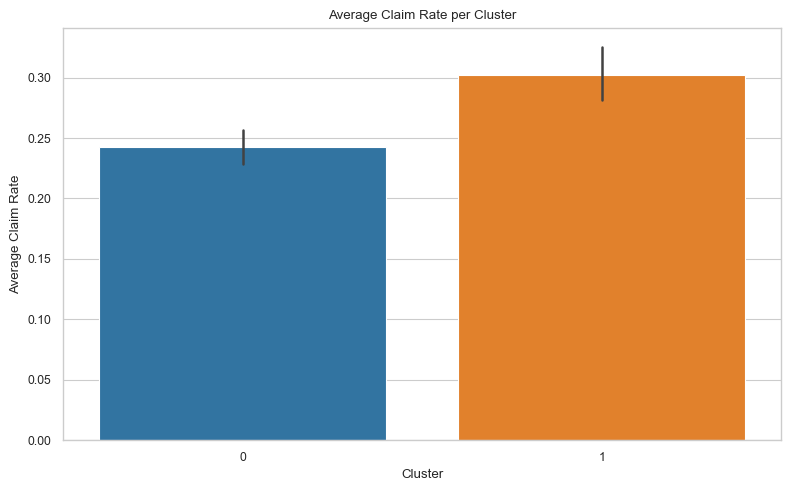

In [29]:
data["Cluster_str"] = data["Cluster"].astype(str)

cluster_order_str = sorted(data["Cluster_str"].unique(), key=int)

base = sns.color_palette("tab10", n_colors=len(cluster_order_str))
palette_map_str = {c: base[i] for i, c in enumerate(cluster_order_str)}


plt.figure(figsize=(8,5))
sns.barplot(
    data=data,
    x="Cluster_str", y="Claim_rate",
    order=cluster_order_str,
    palette=palette_map_str,
    estimator=np.mean
)
plt.title("Average Claim Rate per Cluster")
plt.ylabel("Average Claim Rate")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig("/Users/joakimandersen/Desktop/Machine learning/1ClaimRateClustering", dpi=300, bbox_inches="tight")
plt.show()


meaning higher claim rate connected to high pc1 scores (which is dominated by logbonusmalus and driverage)

In [19]:
print("\nMost common Area per cluster:")
print(data.groupby("Cluster")["Area"].agg(lambda x: x.mode()[0]))
print("\nMost common Region per cluster:")
print(data.groupby("Cluster")["Region"].agg(lambda x: x.mode()[0]))
print("\nMost common Vehicle brand per cluster:")
print(data.groupby("Cluster")["VehBrand"].agg(lambda x: x.mode()[0]))
print("\nMost common Fuel Type per cluster:")
print(data.groupby("Cluster")["VehGas"].agg(lambda x: x.mode()[0]))



Most common Area per cluster:
Cluster
0    C
1    E
Name: Area, dtype: object

Most common Region per cluster:
Cluster
0    R24
1    R24
Name: Region, dtype: object

Most common Vehicle brand per cluster:
Cluster
0    B12
1     B1
Name: VehBrand, dtype: object

Most common Fuel Type per cluster:
Cluster
0    Regular
1    Regular
Name: VehGas, dtype: object


In [21]:
for col in ["Claim_rate", "Exposure", "ClaimNb", "DrivAge", "VehAge", "BonusMalus"]:
    print(f"\n{col}:")
    print(data.groupby("Cluster")[col].describe()[["mean", "std", "min", "max"]])


Claim_rate:
             mean       std  min    max
Cluster                                
0        0.242602  4.379337  0.0  732.0
1        0.302479  4.534329  0.0  366.0

Exposure:
             mean       std       min   max
Cluster                                    
0        0.572116  0.368476  0.002732  2.01
1        0.432725  0.336013  0.002732  1.82

ClaimNb:
             mean       std  min   max
Cluster                               
0        0.050568  0.232632  0.0  11.0
1        0.058795  0.251822  0.0   4.0

DrivAge:
              mean        std   min    max
Cluster                                   
0        51.342332  12.151650  18.0  100.0
1        32.534481   8.468597  18.0   86.0

VehAge:
             mean       std  min    max
Cluster                                
0        6.633201  5.549992  0.0   62.0
1        7.962072  5.795446  0.0  100.0

BonusMalus:
              mean        std   min    max
Cluster                                   
0        51.553807   4.5